,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


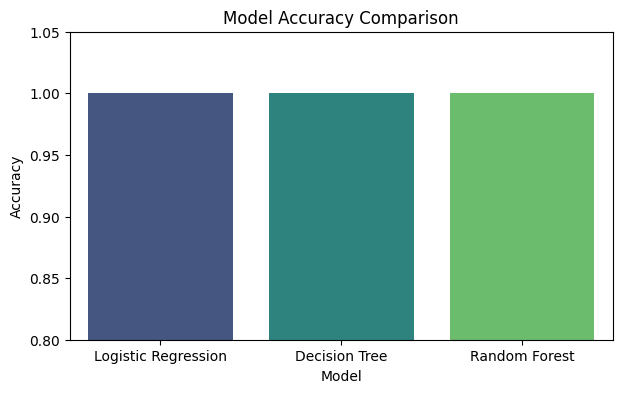

,Model,Before_CV_Accuracy,After_CV_Accuracy,Best_Params,Test_Accuracy,Test_F1
0,Logistic Regression,0.9780,0.9824,{'clf__C': 0.1},0.9737,0.9793
1,Decision Tree,0.9165,0.9319,{'clf__max_depth': 2},0.8947,0.9118
2,Random Forest,0.9626,0.9626,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.9561,0.9655


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = accuracy_score(y_test, preds)

df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
display(df_results)

plt.figure(figsize=(7, 4))
sns.barplot(x='Model', y='Accuracy', data=df_results, hue='Model', legend=False, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.05)
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, penalty='l2'))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=42))
    ])
}

param_grids = {
    'Logistic Regression': {'clf__C': [0.01, 0.1, 1, 10, 100]},
    'Decision Tree': {'clf__max_depth': [2, 3, 4, 5, 6, None]},
    'Random Forest': {'clf__n_estimators': [50, 100, 200], 'clf__max_depth': [3, 5, None]}
}

results = []
grids = {}

for name, pipe in pipelines.items():
    before_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')

    grid = GridSearchCV(pipe, param_grids[name], cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    grids[name] = grid

    best_model = grid.best_estimator_
    test_preds = best_model.predict(X_test)

    results.append({
        'Model': name,
        'Before_CV_Accuracy': round(before_scores.mean(), 4),
        'After_CV_Accuracy': round(grid.best_score_, 4),
        'Best_Params': grid.best_params_,
        'Test_Accuracy': round(accuracy_score(y_test, test_preds), 4),
        'Test_F1': round(f1_score(y_test, test_preds), 4)
    })

df_results = pd.DataFrame(results)
display(df_results)
